# Scalograms

In [17]:
import numpy as np

X_train = np.load("preprocessed/X_train.npy")
X_val   = np.load("preprocessed/X_val.npy")
X_test  = np.load("preprocessed/X_test.npy")
y_train = np.load("preprocessed/y_train.npy")
y_val   = np.load("preprocessed/y_val.npy")
y_test  = np.load("preprocessed/y_test.npy")

print("Loaded preprocessed splits:")
print(f"  X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}  |  y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}  |  y_test  : {y_test.shape}")

Loaded preprocessed splits:
  X_train : (7958, 178)  |  y_train : (7958,)
  X_val   : (1702, 178)  |  y_val   : (1702,)
  X_test  : (1725, 178)  |  y_test  : (1725,)


In [18]:
import numpy as np
import pywt
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

# Load preprocessed splits
X_train = np.load("preprocessed/X_train.npy")
X_val   = np.load("preprocessed/X_val.npy")
X_test  = np.load("preprocessed/X_test.npy")
y_train = np.load("preprocessed/y_train.npy")
y_val   = np.load("preprocessed/y_val.npy")
y_test  = np.load("preprocessed/y_test.npy")

# CWT settings
SCALES   = np.arange(1, 179)  # 178 frequency scales matches 178 time points
WAVELET  = "morl"             # Morlet wavelet - best suited for EEG oscillations
IMG_SIZE = 178                # CWT output is naturally (178, 178) - no resize needed

# Output directory
SAVE_DIR = "scalograms"
os.makedirs(SAVE_DIR, exist_ok=True)


def signal_to_scalogram(signal):
    coefficients, _ = pywt.cwt(signal, SCALES, WAVELET)
    return np.abs(coefficients).astype(np.float32)  # shape: (178, 178)


def generate_and_save(X, y, split_name):
    N = X.shape[0]
    scalograms = np.zeros((N, 1, IMG_SIZE, IMG_SIZE), dtype=np.float32)

    for i in tqdm(range(N), desc=f"Generating {split_name}"):
       scalograms[i, 0] = signal_to_scalogram(X[i])

    x_path = os.path.join(SAVE_DIR, f"X_{split_name}.npy")
    y_path = os.path.join(SAVE_DIR, f"y_{split_name}.npy")

    np.save(x_path, scalograms)
    np.save(y_path, y)

    print(f"  Saved {split_name}:")
    print(f"    {x_path}  —  shape {scalograms.shape}")
    print(f"    {y_path}  —  shape {y.shape}")
    print(f"    Class balance: {y.sum()} seizure / {(y==0).sum()} non-seizure\n")


# Generate all three splits
#print("Starting scalogram generation...\n")
generate_and_save(X_train, y_train, "train")
generate_and_save(X_val,   y_val,   "val")
generate_and_save(X_test,  y_test,  "test")

print("Done. Your scalogram files:")
for fname in sorted(os.listdir(SAVE_DIR)):
    fpath = os.path.join(SAVE_DIR, fname)
    size_mb = os.path.getsize(fpath) / (1024 ** 2)
    print(f"  {fname:<20} {size_mb:.1f} MB")

Generating train: 100%|██████████| 7958/7958 [01:32<00:00, 85.92it/s]


  Saved train:
    scalograms\X_train.npy  —  shape (7958, 1, 178, 178)
    scalograms\y_train.npy  —  shape (7958,)
    Class balance: 1472 seizure / 6486 non-seizure



Generating val: 100%|██████████| 1702/1702 [00:19<00:00, 85.31it/s]


  Saved val:
    scalograms\X_val.npy  —  shape (1702, 1, 178, 178)
    scalograms\y_val.npy  —  shape (1702,)
    Class balance: 414 seizure / 1288 non-seizure



Generating test: 100%|██████████| 1725/1725 [00:20<00:00, 85.10it/s]


  Saved test:
    scalograms\X_test.npy  —  shape (1725, 1, 178, 178)
    scalograms\y_test.npy  —  shape (1725,)
    Class balance: 391 seizure / 1334 non-seizure

Done. Your scalogram files:
  X_test.npy           208.5 MB
  X_train.npy          961.8 MB
  X_val.npy            205.7 MB
  examples.png         0.3 MB
  y_test.npy           0.0 MB
  y_train.npy          0.1 MB
  y_val.npy            0.0 MB


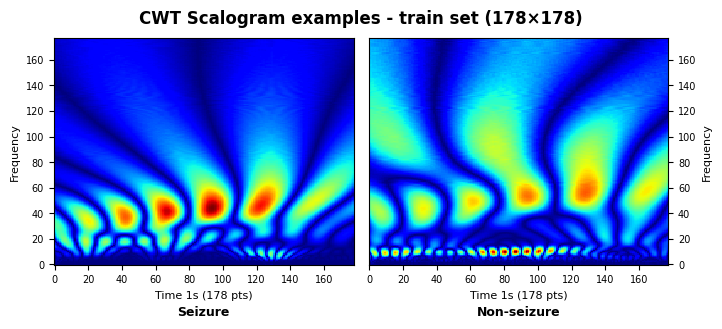

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

SAVE_DIR = "scalograms"

X_train_s = np.load(os.path.join(SAVE_DIR, "X_train.npy"))
y_train_s = np.load(os.path.join(SAVE_DIR, "y_train.npy"))

fig, axes = plt.subplots(1, 2, figsize=(7.16, 3.5))

for i, (ax, label, title) in enumerate(zip(axes, [1, 0], ["Seizure", "Non-seizure"])):
    idx = np.where(y_train_s == label)[0][0]
    ax.imshow(
        X_train_s[idx, 0],
        aspect="auto",
        origin="lower",
        cmap="jet",
        interpolation="nearest"
    )
    ax.set_xlabel("Time 1s (178 pts)", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.text(0.5, -0.18, title, transform=ax.transAxes,
            ha="center", va="top", fontsize=9, fontweight="bold")
    if i == 0:
        ax.set_ylabel("Frequency", fontsize=8)
    else:
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")
        ax.set_ylabel("Frequency", fontsize=8)

plt.suptitle("CWT Scalogram examples - train set (178×178)", fontsize=12, x=0.5, ha="center", fontweight="bold")
plt.tight_layout(pad=0.5)
plt.subplots_adjust(bottom=0.25, top=0.9)
plt.savefig(os.path.join(SAVE_DIR, "examples.png"), dpi=600, bbox_inches="tight")
plt.show()